# Two-step Stress: a tutorial for the cognitive-load two-step task

## What is this package?

`two-step-stress` is a Python implementation of the Daw et al. (2011) two-step decision task, with a within-subject cognitive-load manipulation following Otto et al. (2013). It's aimed at psychology researchers who want to run the task on healthy volunteers and study how working-memory load shifts behaviour between model-based and model-free control.

The package ships the full stack: a pure-logic **engine** (probabilistic transitions, drifting reward walks, the 1-back letter task) — all unit-tested and reproducible from a logged random seed — a PsychoPy **experiment** (Coder mode) that presents the task and writes one CSV per participant, and an **analysis** layer that computes the headline stay-probability figures and the 1-back manipulation check. This tutorial walks through all three.

## Scenario

### Purpose of this scenario

This scenario follows one participant through a single session, so you can see exactly what a volunteer does and sees — from sitting down to the thank-you screen — and, alongside it, what the software records. (For *why* the task is built this way, see "Task structure" below.)

### The participant

**Alex** is a 22-year-old undergraduate volunteer with no prior experience of decision-making experiments. Alex reads English instructions and uses a standard keyboard, but knows nothing about model-based versus model-free control — they are simply told they will "pilot spaceships to find treasure."

### Assumptions & dependencies

- The experimenter's machine runs **Python 3.11** with the package installed for the live task: `pip install -e ".[task,dev]"` (the `task` extra adds **PsychoPy**; see the README for the recommended conda setup). The engine and analysis run without PsychoPy, but presenting the task needs it.
- A keyboard (Alex uses only four keys), a normal display, and a quiet room.
- The experimenter has set the task parameters in `config.py` (200 trials, 4 blocks, timings, key mapping) and launches one session per participant.

### What Alex does, step by step

1. The experimenter runs `python -m two_step_stress.task.run_experiment`, types Alex's ID into a dialog, and hands over the keyboard.
2. Alex reads a **welcome** and a few **instruction** screens (advance with **SPACE**), learning the cover story and the keys, then completes a short **practice** block with explicit COMMON/RARE feedback.
3. On each main trial Alex sees **two spaceships**. In *load* blocks a **letter** flashes above them first.
   - **Input:** press **F** (left ship) or **J** (right ship); in load blocks also press **Z** (the letter matches the previous one) or **M** (no match), within a 2-second window.
4. The chosen ship flies to a **planet** (its *common* destination about 70% of the time, the *rare* one otherwise), where Alex sees **two aliens** and picks one — **input:** **F** / **J** again.
5. Alex sees the outcome — **treasure ("+1")** or **an empty box ("0")** — and the **treasure counter** at the bottom of the screen ticks up on a win.
   - **Output to Alex:** the per-trial feedback and the running treasure counter.
   - **Output to disk:** one **CSV row** for the trial (both choices, both RTs, the transition type, the reward, the 1-back letter/response, and the four reward probabilities at trial start), plus a session **JSON sidecar** (RNG seed, key mapping, refresh rate).
6. After 200 trials across 4 blocks (with breaks between them), Alex reaches a **thank-you screen** showing the total treasure, and the data files are finalised.

If Alex runs out of time on a trial, they see **"Too slow!"**; that trial is logged with blanks, the reward walk is frozen, and the experiment moves on.

## Flowchart: user and software actions

The two columns below mirror one session: on the left, every action **Alex** takes; on the right, what the **software** does in response, with the main functions named. The bracketed middle block — from seeing the spaceships to the reward landing — is a single call to `run_trial()`, repeated 200 times across the four blocks.

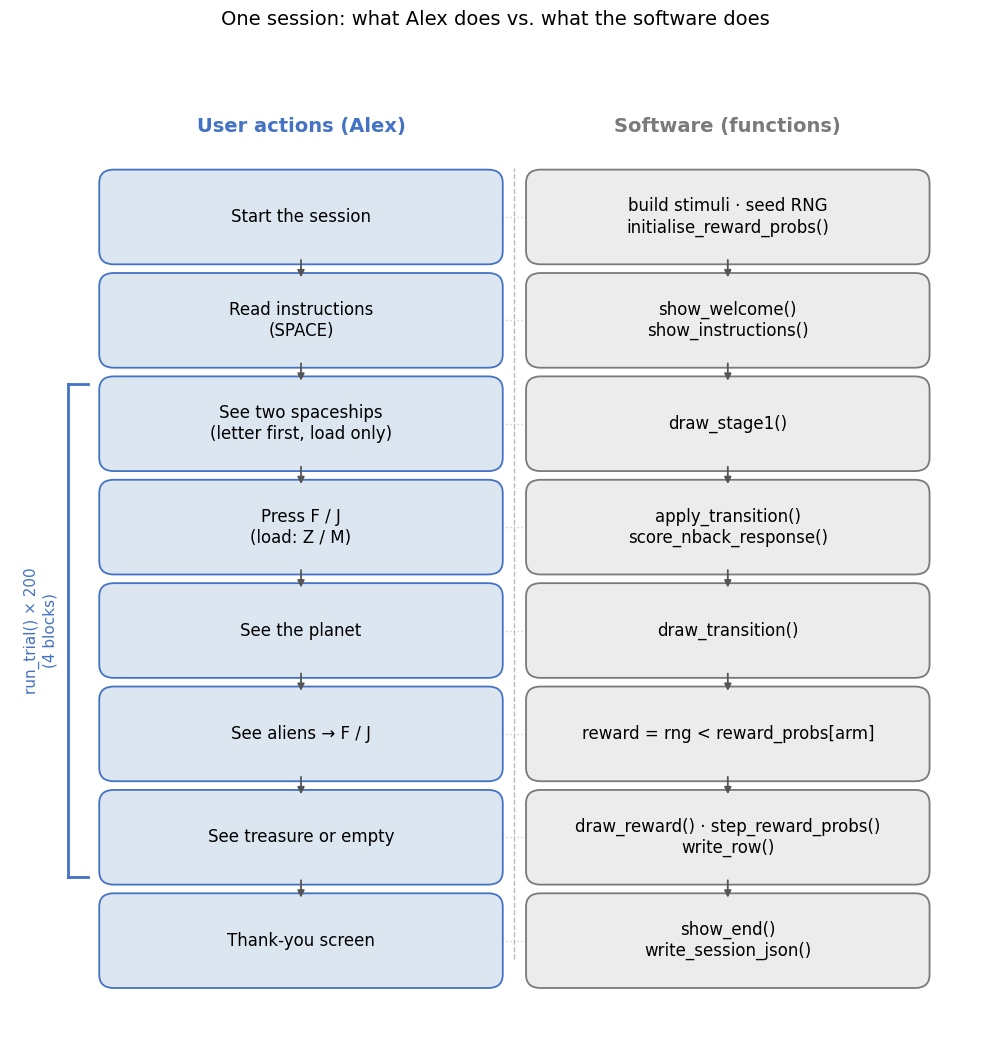

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

USER_FACE, USER_EDGE = "#DCE6F1", "#4472C4"
SW_FACE, SW_EDGE = "#ECECEC", "#7A7A7A"
ARROW = "#555555"
BOX_FS, HEAD_FS = 12, 14

# Concise: short user step on the left, the key function(s) on the right.
steps = [
    ("Start the session", "build stimuli · seed RNG\ninitialise_reward_probs()"),
    ("Read instructions\n(SPACE)", "show_welcome()\nshow_instructions()"),
    ("See two spaceships\n(letter first, load only)", "draw_stage1()"),
    ("Press F / J\n(load: Z / M)", "apply_transition()\nscore_nback_response()"),
    ("See the planet", "draw_transition()"),
    ("See aliens → F / J", "reward = rng < reward_probs[arm]"),
    ("See treasure or empty", "draw_reward() · step_reward_probs()\nwrite_row()"),
    ("Thank-you screen", "show_end()\nwrite_session_json()"),
]

fig, ax = plt.subplots(figsize=(10, 10.5))
ax.set_xlim(0, 1)
ax.set_ylim(-0.05, 1.05)  # padding so top/bottom boxes aren't clipped
ax.axis("off")

LX, RX, DIV = 0.30, 0.74, 0.52
W, H = 0.40, 0.09
top, bot = 0.86, 0.05          # top box centre lowered to clear the headers
HEAD_Y = 0.955
n = len(steps)
ys = [top - i * (top - bot) / (n - 1) for i in range(n)]


def box(x, y, text, face, edge):
    ax.add_patch(FancyBboxPatch(
        (x - W / 2, y - H / 2), W, H,
        boxstyle="round,pad=0.008,rounding_size=0.015",
        linewidth=1.3, edgecolor=edge, facecolor=face))
    ax.text(x, y, text, ha="center", va="center", fontsize=BOX_FS)


ax.text(LX, HEAD_Y, "User actions (Alex)", ha="center", fontsize=HEAD_FS,
        fontweight="bold", color=USER_EDGE)
ax.text(RX, HEAD_Y, "Software (functions)", ha="center", fontsize=HEAD_FS,
        fontweight="bold", color=SW_EDGE)
ax.plot([DIV, DIV], [bot - 0.02, top + H / 2 + 0.01], ls="--", color="#BBBBBB", lw=1)

for i, (u, s) in enumerate(steps):
    y = ys[i]
    ax.plot([LX + W / 2, RX - W / 2], [y, y], ls=":", color="#CFCFCF", lw=1, zorder=0)
    box(LX, y, u, USER_FACE, USER_EDGE)
    box(RX, y, s, SW_FACE, SW_EDGE)
    if i < n - 1:
        for x in (LX, RX):
            ax.annotate("", xy=(x, ys[i + 1] + H / 2), xytext=(x, y - H / 2),
                        arrowprops=dict(arrowstyle="-|>", color=ARROW, lw=1.3))

# Bracket the per-trial loop (steps 3-7 = indices 2..6).
hi, lo = ys[2] + H / 2, ys[6] - H / 2
bx = 0.06
ax.plot([bx, bx], [lo, hi], color=USER_EDGE, lw=2)
ax.plot([bx, bx + 0.02], [hi, hi], color=USER_EDGE, lw=2)
ax.plot([bx, bx + 0.02], [lo, lo], color=USER_EDGE, lw=2)
ax.text(bx - 0.028, (lo + hi) / 2, "run_trial() × 200\n(4 blocks)",
        rotation=90, ha="center", va="center", fontsize=11, color=USER_EDGE)

ax.set_title("One session: what Alex does vs. what the software does",
             fontsize=14, pad=16)
fig.tight_layout()
plt.show()

## Task structure

In the two-step task, every trial starts with a **Stage-1** choice between two options (here, two spaceships). That choice leads *probabilistically* to one of two **Stage-2** states (two planets), where you make a second choice between two options (two aliens) and either get a reward (treasure) or don't. The twist is the transition structure: each Stage-1 choice has one planet it usually goes to — the **common** transition, which fires 70% of the time — and one it rarely goes to — the **rare** transition, the other 30%. These probabilities are fixed for the whole experiment.

The rewards, on the other hand, are not fixed. Each of the four Stage-2 options has its own reward probability that drifts slowly over trials via an independent Gaussian random walk (σ = 0.025), bouncing off reflecting boundaries at 0.25 and 0.75. So the best option keeps changing and a participant has to keep learning. The combination of *fixed transitions* and *drifting rewards* is exactly what lets us tell two strategies apart: a **model-based** one that uses knowledge of the transition structure to plan, versus a **model-free** one that just repeats whatever was rewarded last.

On top of this, the package adds a within-subject **cognitive-load manipulation** following Otto et al. (2013). In *load* blocks, a letter flashes at the start of each trial and the participant has to judge whether it matches the letter from the previous trial — a **1-back task** — pressing a key during the very window they're deliberating about their Stage-1 choice. This ties up working memory exactly when model-based planning would happen. *No-load* blocks are identical but without the letters. The experiment runs 200 trials split into 4 blocks of 50, with load and no-load blocks counterbalanced in **ABBA / BAAB** order across participants so block position can't be confounded with load.

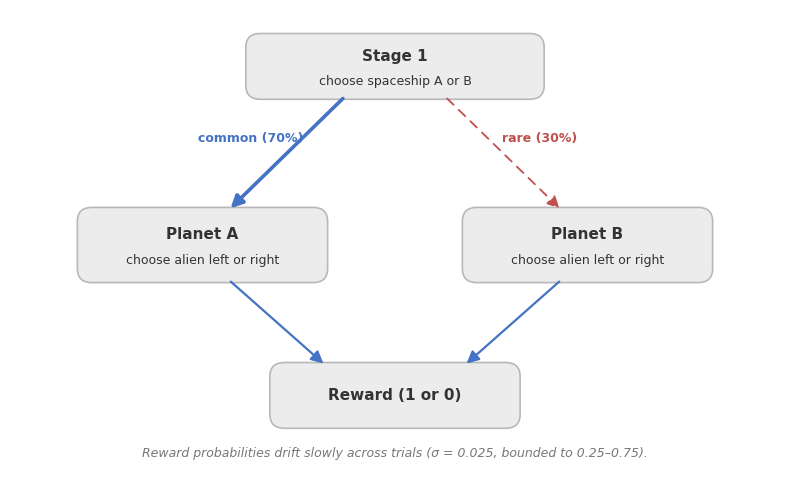

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# Palette: soft greys for boxes; blue = common/reward, red = rare (matches the cell 18 plot).
BOX_FACE, BOX_EDGE, TEXT = "#ECECEC", "#B8B8B8", "#333333"
ACCENT, RARE = "#4472C4", "#C0504D"

fig, ax = plt.subplots(figsize=(8, 5))


def box(cx, cy, w, h, title, subtitle=None):
    """Rounded grey box centred at (cx, cy), with an optional subtitle line."""
    ax.add_patch(FancyBboxPatch(
        (cx - w / 2, cy - h / 2), w, h,
        boxstyle="round,pad=0.1,rounding_size=0.3",
        linewidth=1.2, edgecolor=BOX_EDGE, facecolor=BOX_FACE,
    ))
    if subtitle:
        ax.text(cx, cy + 0.22, title, ha="center", va="center", fontsize=11, weight="bold", color=TEXT)
        ax.text(cx, cy - 0.32, subtitle, ha="center", va="center", fontsize=9, color=TEXT)
    else:
        ax.text(cx, cy, title, ha="center", va="center", fontsize=11, weight="bold", color=TEXT)


def arrow(p0, p1, color, lw, dashed=False):
    ax.add_patch(FancyArrowPatch(
        p0, p1, arrowstyle="-|>", mutation_scale=18,
        linewidth=lw, color=color, shrinkA=4, shrinkB=4,
        linestyle=(0, (5, 4)) if dashed else "-",
    ))


# Nodes (canvas is 16 wide x 10 tall; figsize 8x5 keeps 1 unit square).
box(8, 8.8, 6.0, 1.2, "Stage 1", "choose spaceship A or B")
box(4, 5.0, 5.0, 1.4, "Planet A", "choose alien left or right")
box(12, 5.0, 5.0, 1.4, "Planet B", "choose alien left or right")
box(8, 1.8, 5.0, 1.2, "Reward (1 or 0)")

# Transition arrows: common emphasised (thick, solid), rare de-emphasised (thin, dashed).
arrow((7.0, 8.2), (4.5, 5.7), ACCENT, 2.6)
arrow((9.0, 8.2), (11.5, 5.7), RARE, 1.3, dashed=True)
ax.text(5.0, 7.2, "common (70%)", ha="center", fontsize=9, weight="bold", color=ACCENT)
ax.text(11.0, 7.2, "rare (30%)", ha="center", fontsize=9, weight="bold", color=RARE)

# Reward arrows (both Stage-2 states lead to the same reward outcome).
arrow((4.5, 4.3), (6.6, 2.4), ACCENT, 1.6)
arrow((11.5, 4.3), (9.4, 2.4), ACCENT, 1.6)

# Caption.
ax.text(8, 0.5, "Reward probabilities drift slowly across trials (σ = 0.025, bounded to 0.25–0.75).",
        ha="center", fontsize=9, style="italic", color="#777777")

ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
plt.axis("off")
plt.tight_layout()
plt.show()


## The building blocks

This section walks through the six public functions the package exposes, each with a small runnable example. Together they are the engine the live experiment is built on: the transition logic, the drifting reward walks, and the 1-back letter task. Every function takes an explicit `numpy` random generator, so each example below is fully reproducible.

### `build_transition_mapping`

Sets up which Stage-1 choice commonly leads to which Stage-2 state for a given participant. There are only two possible mappings, and which one a participant gets is decided by their counterbalance ID being even or odd — this keeps the common/rare structure balanced across your sample. The returned dict says, for each Stage-1 action, which Stage-2 state is its *common* destination.

In [3]:
from two_step_stress import build_transition_mapping

print(build_transition_mapping(0))  # even counterbalance ID
print(build_transition_mapping(1))  # odd counterbalance ID

{0: 0, 1: 1}
{0: 1, 1: 0}


### `apply_transition`

Takes a Stage-1 choice and rolls the dice on where the participant ends up. With probability 0.7 they land in the common Stage-2 state for that choice; with probability 0.3 they're bumped to the rare one. It returns both the resulting state and whether the transition was `'common'` or `'rare'` — exactly the information the stay-probability analysis needs later.

In [4]:
import numpy as np
from two_step_stress import apply_transition, build_transition_mapping

rng = np.random.default_rng(0)
mapping = build_transition_mapping(0)
# Take Stage-1 action 0 five times and see where it lands.
print([apply_transition(0, mapping, rng) for _ in range(5)])

[(0, 'common'), (0, 'common'), (0, 'common'), (0, 'common'), (1, 'rare')]


### `initialise_reward_probs`

Sets the starting reward probabilities for the four Stage-2 options. Each is drawn independently and uniformly between 0.25 and 0.75, so no option starts off obviously best. You call this once at the start of a participant's session.

In [5]:
import numpy as np
from two_step_stress import initialise_reward_probs

rng = np.random.default_rng(0)
print(initialise_reward_probs(rng).round(3))

[0.568 0.385 0.27  0.258]


### `step_reward_probs`

Advances those four probabilities by one trial's worth of drift. Each one takes a small Gaussian step (σ = 0.025) and reflects off the boundaries at 0.25 and 0.75 so it never escapes the valid range. Calling this once per trial is what makes the reward landscape slowly shift, forcing participants to keep learning.

In [6]:
import numpy as np
from two_step_stress import initialise_reward_probs, step_reward_probs

rng = np.random.default_rng(0)
probs = initialise_reward_probs(rng)
for _ in range(3):  # walk forward three trials
    probs = step_reward_probs(probs, rng)
    print(probs.round(3))

[0.555 0.394 0.303 0.282]
[0.537 0.362 0.288 0.283]
[0.479 0.357 0.256 0.265]


### `generate_letter_stream`

Builds the sequence of letters for the 1-back task in a load block. It returns the letters plus a parallel list flagging which ones are matches to the previous letter, hitting a target match rate you specify (the package default is about 33%). The first letter is never a match — there's nothing before it.

In [7]:
import numpy as np
from two_step_stress import generate_letter_stream

rng = np.random.default_rng(0)
letters, is_match = generate_letter_stream(8, 0.33, rng)
print(letters)
print(is_match)

['W', 'W', 'W', 'W', 'P', 'M', 'R', 'N']
[False, True, True, True, False, False, False, False]


### `score_nback_response`

Grades a participant's 1-back keypress. Given whether the current letter really was a match and which key they pressed, it returns whether they were correct and the signal-detection label for the response — `'hit'`, `'miss'`, `'false_alarm'`, or `'correct_rejection'`. Those labels feed straight into the 1-back accuracy manipulation check.

In [8]:
from two_step_stress import score_nback_response

# Letter was a match and they pressed the match key 'z' -> a hit.
print(score_nback_response(True, "z", key_match="z", key_no_match="m"))
# Letter was not a match but they pressed 'z' anyway -> a false alarm.
print(score_nback_response(False, "z", key_match="z", key_no_match="m"))

(True, 'hit')
(False, 'false_alarm')


## Using the software

### Install and run

With **Python 3.11** and the package installed for the task layer (`pip install -e ".[task,dev]"` — see the README for the recommended conda environment), launch a session from the repo root:

```bash
python -m two_step_stress.task.run_experiment          # a dialog asks for the participant ID
# piloting flags: --participant P01  --windowed  --no-practice  --trials 5
```

Each run writes `data/raw/sub-<id>_<timestamp>.csv` plus a `_session.json` sidecar. To analyse a finished session:

```bash
python scripts/run_analysis.py --csv data/raw/sub-<id>_<timestamp>.csv
```

### The interface

The window runs full-screen (or 1280×720 with `--windowed`) on a black background, and the participant uses only **F / J** (choices) and **Z / M** (the 1-back). A running **treasure counter** sits at the bottom of every screen. The screens, in order:

- **Welcome screen** — the cover story; advance with SPACE.

![Welcome and instructions screen](screenshots/Welcome-1.png)

- **Stage 1 — two spaceships.** The left/right ships are colour-coded; in load blocks a letter flashes above them for the first 500 ms while the participant deliberates.

![Stage 1: two spaceships with the 1-back letter above (load block)](screenshots/Letter.png)

- **Transition reveal** — the chosen ship arrives at a planet (blue or red); in practice the word COMMON / RARE is shown across it.

![Transition reveal: the chosen ship arrives at a planet](screenshots/Land-blue.png)

- **Stage 2 — two aliens** on the planet-coloured backdrop; press F / J to choose.

![Stage 2: two aliens on the planet-coloured backdrop](screenshots/Blue-planet.png)

- **Reward feedback** — treasure ("+1") or an empty outcome ("0"); the counter updates.

![Reward feedback: treasure earned](screenshots/Treasure-green.png)

Stimuli are deliberately simple geometric shapes, matching the abstract-stimulus tradition of Daw/Otto; `screens.py` keeps localised image-swap seams (`_rocket` / `_alien` / `_planet` / `_disc`) so richer art could be dropped in later.

## Example application: MB vs MF agents

To convince ourselves the engine actually behaves like the two-step task should, we can simulate agents playing it and check the result against a known prediction from Daw et al. (2011, Figure 2). The key measure is **stay probability**: the chance a participant repeats their previous Stage-1 choice, broken down by whether the last trial was rewarded and whether the last transition was common or rare.

The two textbook patterns are:

- A **model-free** agent only cares whether the last choice was rewarded. Its stay probability depends on reward alone — the common/rare distinction makes no difference, so the bars come out flat within each reward condition.
- A **model-based** agent uses the transition structure. After a *rare* transition it knows the reward really belongs to the *other* Stage-1 choice, so reward and transition interact — producing a crossover: stay is high after rewarded-common and unrewarded-rare, low after rewarded-rare and unrewarded-common.

Below we run both agents through 5,000 trials of the real `apply_transition` / `step_reward_probs` engine and plot the result.

> **Note:** the MF agent in this notebook uses a simplified update rule (`q1[a1] += α·(r − q1[a1])`) for pedagogical clarity. The more formally-correct SARSA(λ=0) update used in `scripts/sanity_check.py` is `q1[a1] += α·(r − q2[s2,a2])`; both produce the same qualitative MF signature (flat across common/rare within each reward condition).

MF: rewarded(common=0.82, rare=0.78)  unrewarded(common=0.52, rare=0.54)
MB: rewarded(common=0.60, rare=0.45)  unrewarded(common=0.47, rare=0.60)


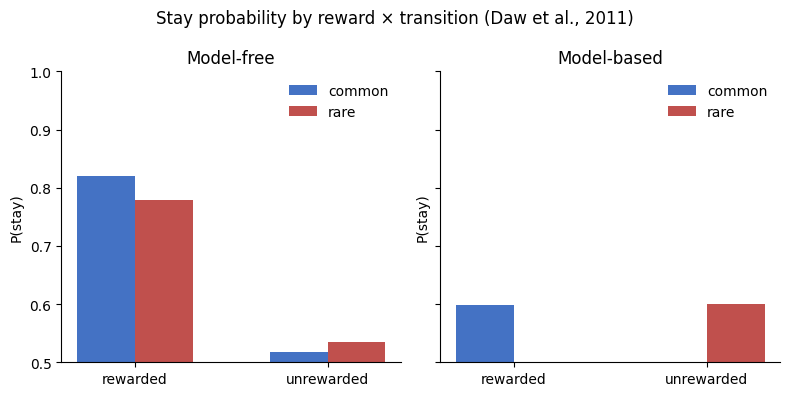

In [9]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from two_step_stress import (
    build_transition_mapping,
    apply_transition,
    initialise_reward_probs,
    step_reward_probs,
)
from two_step_stress.config import P_COMMON, P_RARE

N_TRIALS = 5_000
ALPHA = 0.3   # learning rate
BETA = 5.0    # softmax inverse temperature
SEED = 42


def softmax_choice(q, rng):
    """Pick an action from a softmax over action values q."""
    e = np.exp(BETA * (q - q.max()))
    return int(rng.choice(len(q), p=e / e.sum()))


def simulate(mode, rng):
    """Run one agent ('mf' or 'mb') through the task; return (choice, reward, transition) per trial."""
    mapping = build_transition_mapping(0)
    reward_probs = initialise_reward_probs(rng)
    q2 = np.full((2, 2), 0.5)  # Stage-2 values [state, action]
    q1 = np.full(2, 0.5)       # Stage-1 values (MF updates these; MB recomputes them)

    records = []
    for _ in range(N_TRIALS):
        # Model-based agent re-derives Stage-1 values from Stage-2 values each trial,
        # weighting by the known 70/30 transition structure.
        if mode == "mb":
            q1 = np.array([
                P_COMMON * q2[mapping[a]].max() + P_RARE * q2[1 - mapping[a]].max()
                for a in range(2)
            ])
        a1 = softmax_choice(q1, rng)

        s2, transition = apply_transition(a1, mapping, rng)
        a2 = softmax_choice(q2[s2], rng)
        reward = int(rng.random() < reward_probs[s2 * 2 + a2])

        # Learn: update the chosen Stage-2 value; MF also updates Stage-1 from reward directly.
        q2[s2, a2] += ALPHA * (reward - q2[s2, a2])
        if mode == "mf":
            q1[a1] += ALPHA * (reward - q1[a1])

        reward_probs = step_reward_probs(reward_probs, rng)
        records.append((a1, reward, transition))
    return records


def stay_matrix(records):
    """P(repeat Stage-1 choice) split by previous reward (0/1) x transition (common/rare)."""
    counts = {r: {t: [0, 0] for t in ("common", "rare")} for r in (0, 1)}
    for i in range(1, len(records)):
        prev_a1, prev_r, prev_t = records[i - 1]
        counts[prev_r][prev_t][0] += int(records[i][0] == prev_a1)
        counts[prev_r][prev_t][1] += 1
    return {r: {t: counts[r][t][0] / counts[r][t][1] for t in ("common", "rare")} for r in (0, 1)}


def plot_panel(ax, mat, title):
    x, w = np.array([0.0, 1.0]), 0.3
    ax.bar(x - w / 2, [mat[1]["common"], mat[0]["common"]], w, label="common", color="#4472C4")
    ax.bar(x + w / 2, [mat[1]["rare"], mat[0]["rare"]], w, label="rare", color="#C0504D")
    ax.set_xticks(x)
    ax.set_xticklabels(["rewarded", "unrewarded"])
    ax.set_ylim(0.5, 1.0)
    ax.set_ylabel("P(stay)")
    ax.set_title(title)
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)


mf = stay_matrix(simulate("mf", np.random.default_rng(SEED)))
mb = stay_matrix(simulate("mb", np.random.default_rng(SEED + 1)))

for name, mat in [("MF", mf), ("MB", mb)]:
    print(f"{name}: rewarded(common={mat[1]['common']:.2f}, rare={mat[1]['rare']:.2f})  "
          f"unrewarded(common={mat[0]['common']:.2f}, rare={mat[0]['rare']:.2f})")

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
plot_panel(axes[0], mf, "Model-free")
plot_panel(axes[1], mb, "Model-based")
fig.suptitle("Stay probability by reward × transition (Daw et al., 2011)")
fig.tight_layout()
plt.show()

The two panels show exactly the predicted split. The **model-free** agent's bars are essentially flat within each reward condition — common and rare sit at the same height, so only *whether* the last trial paid off matters. The **model-based** agent shows the crossover: stay probability is high after rewarded-common and unrewarded-rare trials, and low after rewarded-rare and unrewarded-common ones, because it reasons through the transition structure instead of just repeating what worked. Getting both patterns out of the same `apply_transition` / `step_reward_probs` code the live task uses is good evidence the engine is behaving correctly.

## Results: one participant's data

To check that the whole stack actually works together — engine, experiment, logging, and analysis — we ran one participant (the package author, ID `zoi01`) through a complete session: 12 practice trials followed by the full 200 main trials, with the 1-back load manipulation active in two of the four blocks.

This is **n = 1 pilot data**. It is not a scientific result, and nothing below should be read as a substantive claim about cognition. The point is purely a demonstration: that a real session flows from the PsychoPy task into a per-participant CSV, and that the analysis pipeline turns that CSV into the headline figures without falling over — including the messy parts, like trials that timed out.

In [10]:
from pathlib import Path
import matplotlib.pyplot as plt

from two_step_stress.analysis.io import load_session, clean_for_stay_analysis
from two_step_stress.analysis.manipulation_check import nback_accuracy
from two_step_stress.analysis.stay_probability import compute_stay_probability
from two_step_stress.analysis.plots import (
    plot_stay_probability_2x2,
    plot_stay_probability_by_load,
)

# Resolve the CSV whether this notebook runs from the repo root or from docs/.
csv_path = Path("data/raw/sub-zoi01_20260526-093111.csv")
if not csv_path.exists():
    csv_path = Path("..") / csv_path

df_full = load_session(csv_path)
df_clean = clean_for_stay_analysis(df_full)

print(f"Full session : {len(df_full)} rows (12 practice + 200 main)")
print(f"After cleaning: {len(df_clean)} completed main-task trials")

Full session : 212 rows (12 practice + 200 main)
After cleaning: 161 completed main-task trials


Of the 200 main-task trials, **39 (about 20%) timed out** — no Stage-1 or Stage-2 choice inside the 2-second window — so they carry no transition or reward and are dropped by `clean_for_stay_analysis`. That is a high rate, and an honest one to report: it reflects a first-time participant under a genuine dual-task burden (tracking the 1-back letter while deliberating), and a trained participant would time out far less often. For this demo the relevant point is that the pipeline records, flags, and drops missing data correctly rather than crashing or silently miscounting.

In [11]:
acc = nback_accuracy(df_full)
print(f"overall_accuracy = {acc['overall_accuracy']:.2f}")
print("per_block_accuracy = { " +
      ", ".join(f"{b}: {a:.2f}" for b, a in acc['per_block_accuracy'].items()) + " }")
print(f"n_responded = {acc['n_responded']}, n_missed = {acc['n_missed']}")

overall_accuracy = 0.60
per_block_accuracy = { 2: 0.67, 3: 0.53 }
n_responded = 40, n_missed = 60


Overall 1-back accuracy is **60%** — above the 50% chance line, but below the ~75–80% Otto et al. (2013) typically report. Together with the 60 missed letters, that says the secondary task was genuinely hard for this participant, but it *did* engage: responses are reliably better than guessing, so the manipulation was taxing working memory rather than being ignored.

 reward transition  stay_prob  n_trials
      0     common   0.647059        34
      0       rare   0.500000        20
      1     common   0.777778        45
      1       rare   0.782609        23


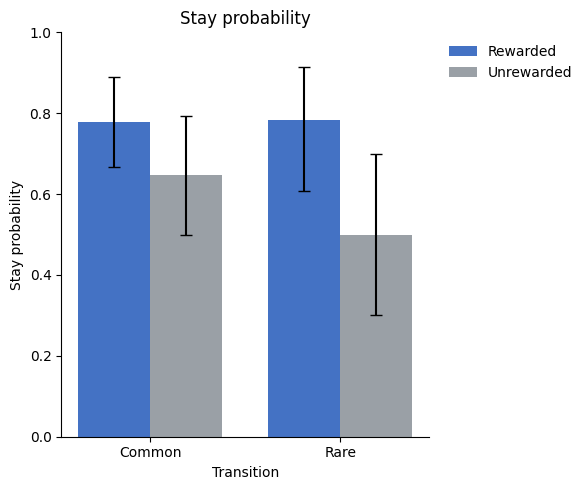

In [12]:
stay_df = compute_stay_probability(df_clean)
print(stay_df[["reward", "transition", "stay_prob", "n_trials"]].to_string(index=False))

fig = plot_stay_probability_2x2(stay_df)

Recall the textbook split from the simulation above: a **model-based** learner produces a *crossover* (stay high after rewarded-common and unrewarded-rare, low after rewarded-rare and unrewarded-common), whereas a **model-free** learner shows a flat main effect of reward. This single participant looks mostly **model-free**: stay probability is high and essentially equal after rewarded-common (≈0.78) and rewarded-rare (≈0.78) — reward matters, transition barely does. The one asymmetry, unrewarded-common (≈0.65) sitting *above* unrewarded-rare (≈0.50), actually runs *opposite* to the model-based prediction (which wants unrewarded-rare higher) and most likely reflects perseveration or noise. The bootstrap error bars are wide — some cells hold only ~20 trials at n=1 — so none of this is significant. It is a sanity check that the figure computes and reads sensibly, not evidence for a control strategy.

 reward transition block_type  stay_prob  n_trials
      0     common       load   0.666667         6
      0     common    no_load   0.642857        28
      0       rare       load   0.666667         3
      0       rare    no_load   0.470588        17
      1     common       load   0.888889         9
      1     common    no_load   0.750000        36
      1       rare       load   1.000000         6
      1       rare    no_load   0.705882        17


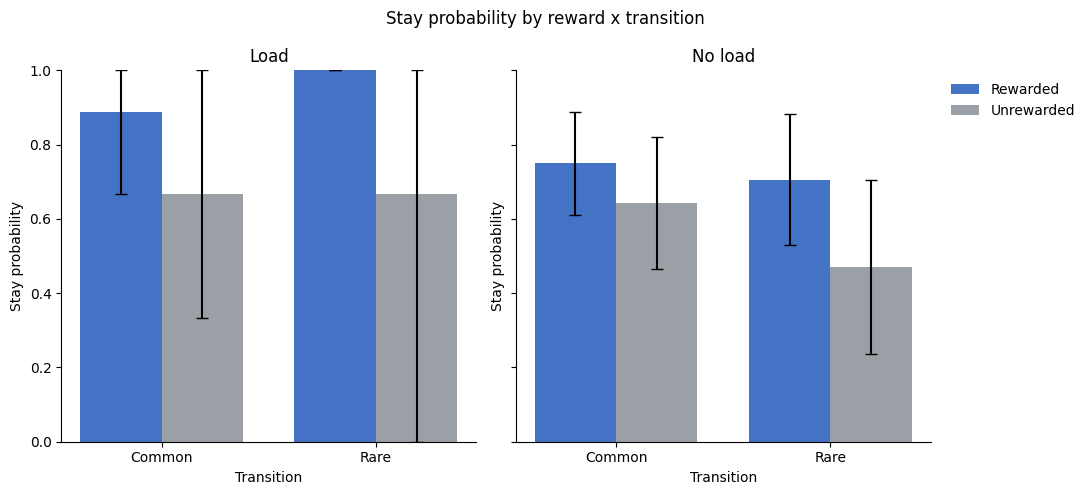

In [13]:
stay_split = compute_stay_probability(df_clean, split_by_block_type=True)
print(stay_split[["reward", "transition", "block_type", "stay_prob", "n_trials"]].to_string(index=False))

fig = plot_stay_probability_by_load(stay_split)

Splitting by block type is where n=1 really bites: the load condition has only ~3–9 usable trial-pairs per cell, so those bars are essentially noise and should not be read as a pattern. The no-load panel is a little better populated and shows the same mostly-reward-driven shape as the pooled plot, without a clean model-based crossover. Otto et al. (2013) predict that working-memory load *reduces* model-based control, so the right comparison — does the crossover shrink under load? — is exactly what this two-panel figure is built to show; we simply cannot evaluate it from one underpowered participant. The takeaway here is structural: the split, the per-cell counts, and the side-by-side figure all generate correctly.

**In short:** the pipeline works end-to-end — a live session becomes a CSV, and the CSV becomes the manipulation-check and stay-probability figures, missing data and all. The qualitative read of this single pilot participant is mostly model-free with no clean load effect, which is exactly what we should expect at n=1; a real test of Otto et al.'s prediction would require a properly powered sample.

## What's next

The engine, the live PsychoPy experiment, the per-participant logging, and the analysis pipeline are all in place and demonstrated above on one pilot participant. The natural next steps are about turning this working paradigm into an actual study:

- **A properly powered sample.** The single-participant pilot only shows the pipeline runs end-to-end. Testing Otto et al.'s prediction — that working-memory load shifts control toward model-free behaviour — needs a real cohort, with enough participants and trials to estimate the load × reward × transition interaction with any confidence.
- **Hybrid reinforcement-learning model fitting.** Beyond the model-agnostic stay-probability plot, fitting the Daw hybrid model (β_MB, β_MF, α, λ, π) per participant would quantify the model-based weight directly, and let us test whether β_MB drops under load.
- **Comparison across populations.** The same task could contrast groups where model-based control is theorised to differ — for example by age, or in relation to compulsivity or acute stress.
- **Online deployment.** Porting the task to the browser (e.g. jsPsych) would make larger samples far easier to collect, at the cost of the millisecond timing precision the local PsychoPy version buys.

None of these change the core paradigm — they build directly on the same engine and analysis layer this tutorial has walked through.